In [89]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import scipy as sp
from scipy.stats import kendalltau

##  Zadanie 1, część 1 

10. W zakładce Graph Data Science zaaplikuj następujące algorytmy:

(a) Stopień węzła (degree centrality),
![degree_centrality](screenshots/10a.png)

(b) Pagerank,
![pagerank](screenshots/10b.png)

11. Zaaplikuj styl dla pagerank oraz wyeksportuj sieć jako obraz (EXPORT> Export screenshot)
![pagerank_style](screenshots/11.svg)

13. Wyeksportuj widok gdzie bedą tylko wierzchołki o stopniu węzła wyższymniz 12 (wykorzystaj slicer),
![degree_slicer](screenshots/13.svg)

## Zadanie 1, część 2
### Grafy losowe (model Erdős-Rényi)

(a) Wygeneruj sieć Erdős-Rényi o N = 100 i p = 0.05,

In [90]:
G = nx.erdos_renyi_graph(n=100, p=0.05, seed=11)

(b) Wylistuj wszystkie wierzchołki i krawędzie,

In [91]:
print("Nodes:", list(G.nodes()))
print("Edges:", list(G.edges()))
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
Edges: [(0, 16), (0, 22), (0, 27), (0, 51), (1, 23), (1, 41), (1, 56), (1, 57), (1, 61), (1, 99), (2, 11), (2, 49), (2, 51), (2, 56), (2, 59), (2, 63), (2, 74), (3, 25), (3, 63), (3, 89), (4, 41), (4, 54), (4, 74), (4, 84), (5, 17), (5, 34), (5, 55), (5, 74), (5, 76), (6, 40), (7, 34), (8, 9), (8, 33), (8, 43), (8, 61), (8, 99), (9, 15), (9, 60), (9, 67), (10, 34), (10, 45), (10, 57), (11, 29), (11, 39), (11, 40), (11, 97), (12, 24), (12, 56), (12, 63), (12, 77), (12, 96), (13, 17), (13, 25), (13, 39), (13, 72), (13, 86), (13, 97), (14, 15), (14, 35), (14, 36), (14, 73), (14, 84), (15, 23), (15,

(c) Oblicz stopień (degree) każdego węzła a następnie stwórz histogramstopni węzłów,

{0: 4, 1: 6, 2: 7, 3: 3, 4: 4, 5: 5, 6: 1, 7: 1, 8: 5, 9: 4, 10: 3, 11: 5, 12: 5, 13: 6, 14: 5, 15: 4, 16: 7, 17: 6, 18: 2, 19: 1, 20: 5, 21: 6, 22: 5, 23: 4, 24: 6, 25: 8, 26: 5, 27: 2, 28: 5, 29: 4, 30: 1, 31: 4, 32: 4, 33: 7, 34: 10, 35: 10, 36: 4, 37: 7, 38: 5, 39: 2, 40: 8, 41: 5, 42: 7, 43: 6, 44: 5, 45: 6, 46: 5, 47: 2, 48: 3, 49: 7, 50: 3, 51: 5, 52: 9, 53: 6, 54: 1, 55: 6, 56: 5, 57: 8, 58: 2, 59: 5, 60: 8, 61: 7, 62: 4, 63: 5, 64: 2, 65: 7, 66: 3, 67: 6, 68: 6, 69: 4, 70: 4, 71: 4, 72: 4, 73: 6, 74: 5, 75: 7, 76: 5, 77: 9, 78: 4, 79: 4, 80: 3, 81: 5, 82: 4, 83: 4, 84: 5, 85: 1, 86: 3, 87: 3, 88: 3, 89: 3, 90: 5, 91: 4, 92: 5, 93: 6, 94: 4, 95: 5, 96: 6, 97: 6, 98: 1, 99: 4}


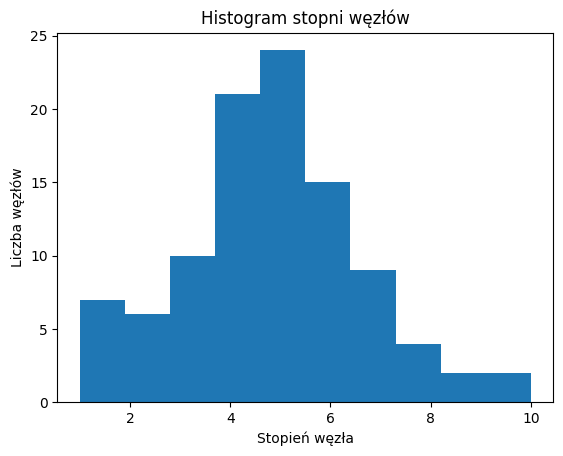

In [92]:
degrees = dict(G.degree())
print(degrees)

plt.hist(list(degrees.values()), bins=10)
plt.xlabel("Stopień węzła")
plt.ylabel("Liczba węzłów")
plt.title("Histogram stopni węzłów")
plt.show()

### (d) Przygotowanie `DataFrame` i opisu statystycznego

Utwórz ramkę danych (`DataFrame`) oraz jej opis statystyczny z wykorzystaniem funkcji `describe()`.

`DataFrame` powinien zawierać metryki obliczone dla wygenerowanej sieci losowej, przy czym:

- każdy wiersz odpowiada pojedynczemu wierzchołkowi grafu,
- indeksem ramki danych jest numer wierzchołka grafu.

Uwzględnij następujące metryki:

1. **Betweenness centrality** (przewodnictwo),
2. **Closeness centrality** (bliskość),
3. **Clustering coefficient** (współczynnik grupowania),
4. **PageRank**,
5. **Average shortest path length** (średnia długość najkrótszej ścieżki w sieci),
6. **Diameter** (średnica sieci),
7. **Number of connected components** (liczba komponentów),
8. **Network density** (gęstość sieci).


In [93]:
betweenness = nx.betweenness_centrality(G)
closeness = nx.closeness_centrality(G)
clustering = nx.clustering(G)
pagerank = nx.pagerank(G)

In [94]:
largest_cc = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_cc)

avg_shortest_path = nx.average_shortest_path_length(G_sub)
diameter = nx.diameter(G_sub)
num_components = nx.number_connected_components(G)
density = nx.density(G)

In [95]:
df = pd.DataFrame({
    "betweenness_centrality": betweenness,
    "closeness_centrality": closeness,
    "clustering_coefficient": clustering,
    "pagerank": pagerank,
    "avg_shortest_path": avg_shortest_path,
    "diameter": diameter,
    "num_components": num_components,
    "density": density
})

df.index.name = "node"
df.head(10)

,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,num_components,density
node,,,,,,,,
0,0.023029,0.306502,0.000000,0.009317,3.134747,6,1,0.048081
1,0.023747,0.347368,0.066667,0.011761,3.134747,6,1,0.048081
2,0.042777,0.354839,0.047619,0.013833,3.134747,6,1,0.048081
3,0.003801,0.293769,0.333333,0.007099,3.134747,6,1,0.048081
4,0.026671,0.295522,0.000000,0.010051,3.134747,6,1,0.048081
5,0.039347,0.356115,0.000000,0.010598,3.134747,6,1,0.048081
6,0.000000,0.277311,0.000000,0.003190,3.134747,6,1,0.048081
7,0.000000,0.279661,0.000000,0.003228,3.134747,6,1,0.048081
8,0.013409,0.319355,0.100000,0.009931,3.134747,6,1,0.048081


In [96]:
df.describe().style.format("{:.6f}")

,betweenness_centrality,closeness_centrality,clustering_coefficient,pagerank,avg_shortest_path,diameter,num_components,density
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.021783,0.322898,0.055913,0.010000,3.134747,6.000000,1.000000,0.048081
std,0.017552,0.034306,0.085837,0.003438,0.000000,0.000000,0.000000,0.000000
min,0.000000,0.228637,0.000000,0.003190,3.134747,6.000000,1.000000,0.048081
25%,0.008574,0.307215,0.000000,0.008222,3.134747,6.000000,1.000000,0.048081
50%,0.019181,0.325658,0.000000,0.010156,3.134747,6.000000,1.000000,0.048081
75%,0.030080,0.340499,0.100000,0.011927,3.134747,6.000000,1.000000,0.048081
max,0.082039,0.392857,0.333333,0.020334,3.134747,6.000000,1.000000,0.048081


e) Ile jest komponentów (connected components) w grafie

In [97]:
print(f"Number of connected components: {nx.number_connected_components(G)}")

for i, comp in enumerate(nx.connected_components(G)):
    print(f"Component {i}: {comp}")

Number of connected components: 1
Component 0: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99}


(f) Zwizualizuj graf w taki sposób, aby rozmiar węzłów odpowiadał mierzePageRank,

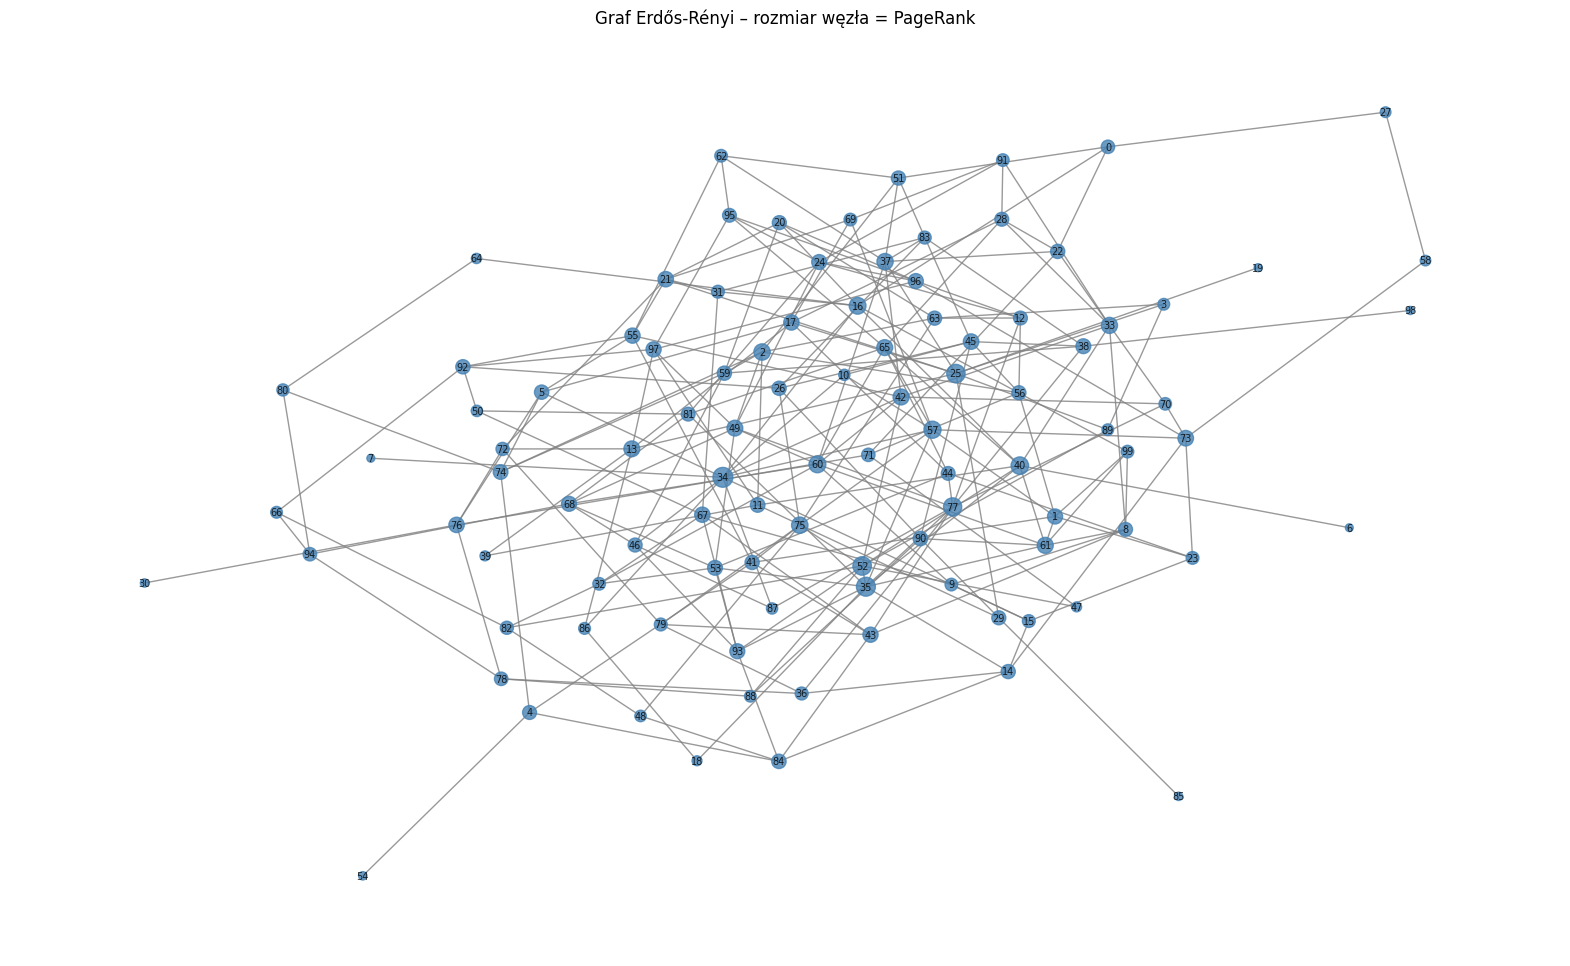

In [98]:
node_sizes = [pagerank[node] * 10000 for node in G.nodes()]

plt.figure(figsize=(20, 12))
pos = nx.spring_layout(G, seed=42)

nx.draw_networkx(
    G,
    pos=pos,
    node_size=node_sizes,
    node_color="steelblue",
    edge_color="gray",
    with_labels=True,
    font_size=7,
    alpha=0.8
)

plt.title("Graf Erdős-Rényi – rozmiar węzła = PageRank")
plt.axis("off")
plt.show()

## Punkt 2

(a) Wygeneruj graf wedle modelu Barabási-Albert z N = 1000 i m0=m = 3

(b) Zwizualizuj graf layoutem Kamada-Kawai

> Są przedstawione dwie analizy, krótka dla 1000 węzłów (zgodna z poleceniem) oraz pełna dla 100 węzłów (dla porównania i lepszej wizualizacji).

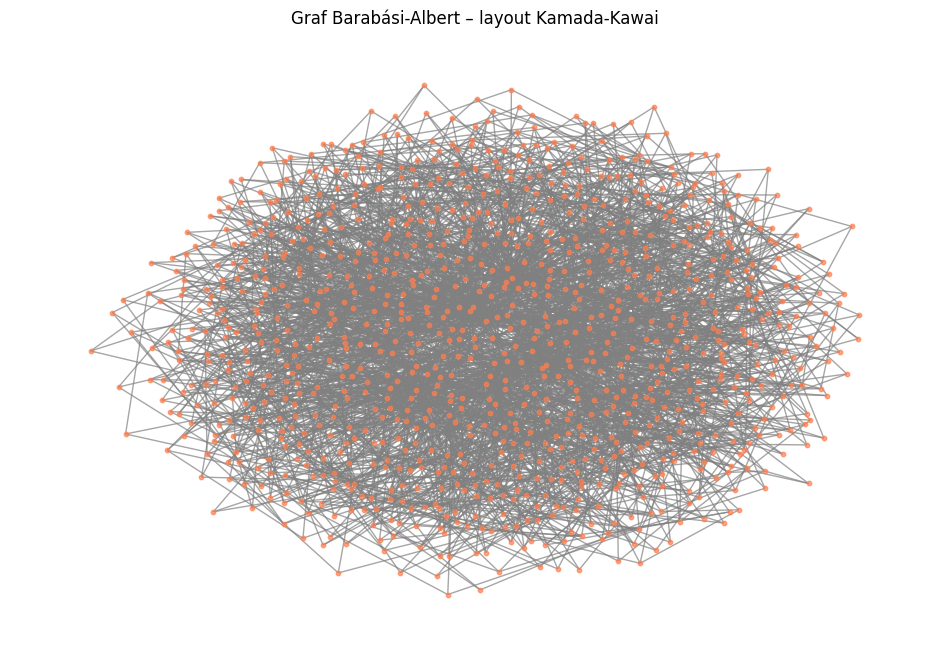

In [99]:
G_ba_big = nx.barabasi_albert_graph(n=1000, m=3, seed=11)

plt.figure(figsize=(12, 8))
pos_kk = nx.kamada_kawai_layout(G_ba_big)

nx.draw_networkx(
    G_ba_big,
    pos=pos_kk,
    node_size=10,
    node_color="coral",
    edge_color="gray",
    with_labels=False,
    alpha=0.7
)

plt.title("Graf Barabási-Albert – layout Kamada-Kawai")
plt.axis("off")
plt.show()

(c) Znajdź najbardziej centralny węzeł według miary pośrednictwa (be-tweenness), jaki ma numer?

(d) Jaka jest średnica grafu?

In [100]:
betweenness_ba = nx.betweenness_centrality(G_ba_big)

most_central = max(betweenness_ba, key=betweenness_ba.get)
print(f"Most central node: {most_central}")
print(f"Betweenness value: {betweenness_ba[most_central]:.4f}")

diameter_ba = nx.diameter(G_ba_big)
print(f"Diameter of BA graph: {diameter_ba}")

Most central node: 2
Betweenness value: 0.1753
Diameter of BA graph: 6


**Analiza dla 100 węzłów**

(a) Wygeneruj graf wedle modelu Barabási-Albert z **N = 100** i m0=m = 3
    
(b) Zwizualizuj graf layoutem Kamada-Kawa

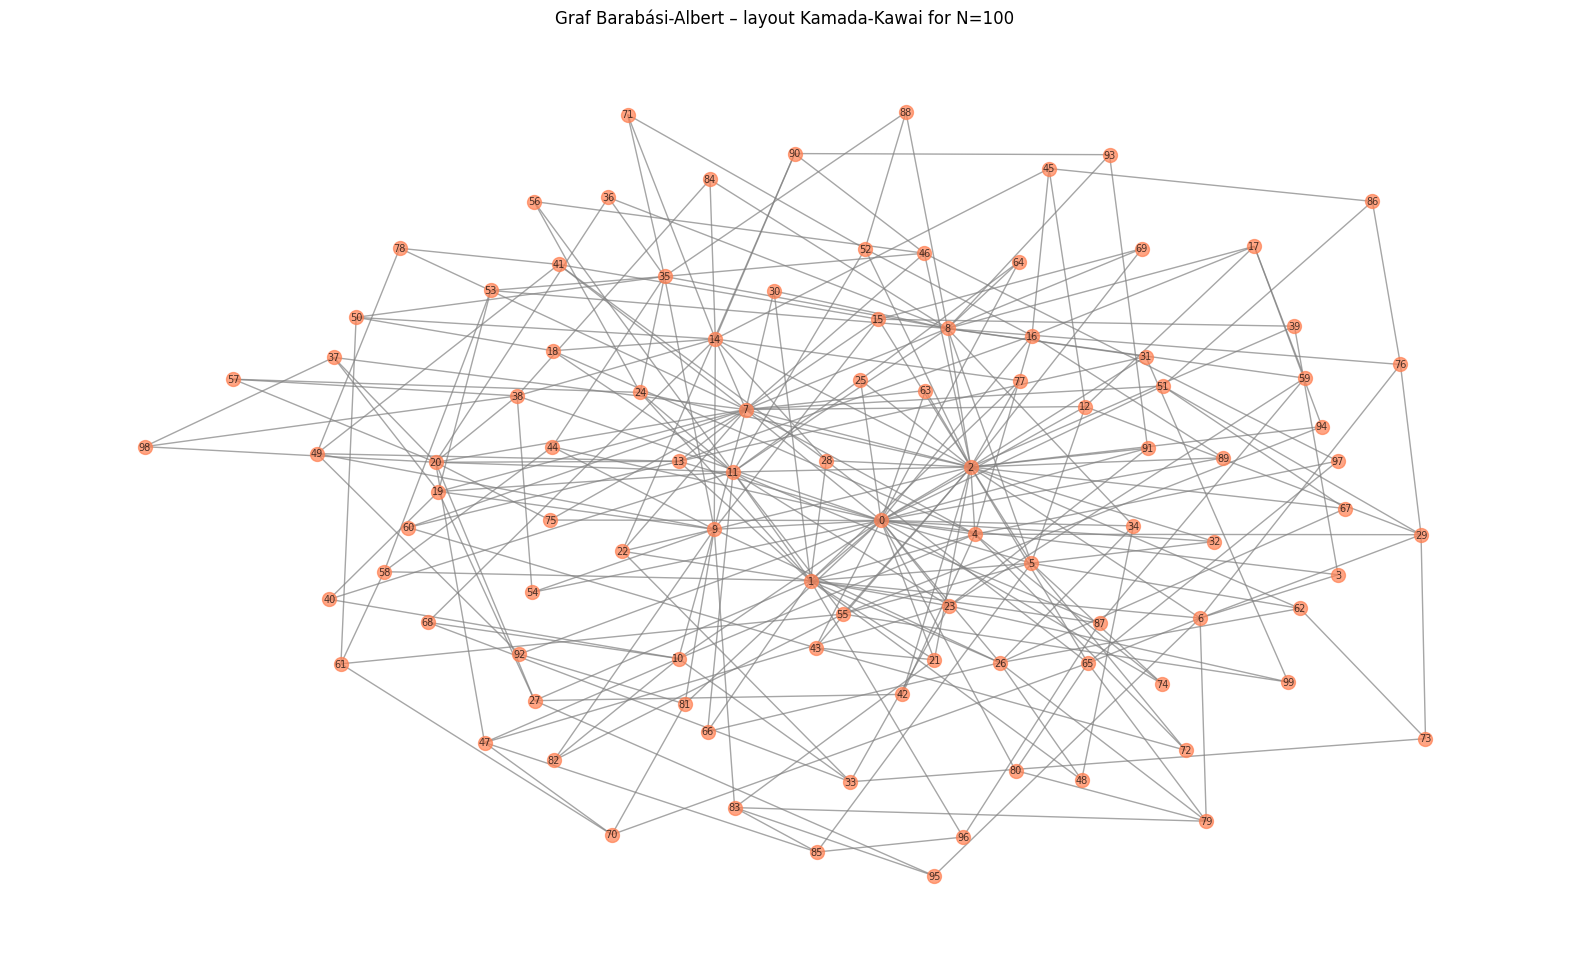

In [114]:
G_ba = nx.barabasi_albert_graph(n=100, m=3, seed=11)

plt.figure(figsize=(20, 12))
pos_kk = nx.kamada_kawai_layout(G_ba)

nx.draw_networkx(
    G_ba,
    pos=pos_kk,
    node_size=100,
    node_color="coral",
    edge_color="gray",
    with_labels=True,
    font_size=7,
    alpha=0.7
)

plt.title("Graf Barabási-Albert – layout Kamada-Kawai for N=100")
plt.axis("off")
plt.show()

In [102]:
betweenness_ba = nx.betweenness_centrality(G_ba)

most_central = max(betweenness_ba, key=betweenness_ba.get)
print(f"Most central node: {most_central}")
print(f"Betweenness value: {betweenness_ba[most_central]:.4f}")

diameter_ba = nx.diameter(G_ba)
print(f"Diameter of BA graph: {diameter_ba}")

Most central node: 2
Betweenness value: 0.2165
Diameter of BA graph: 5


## 3. Praca z rzeczywistymi danymi

(a) Zaimportuj zbiór out.radoslaw_email_email i zachowaj tylko pier-wsze dwie kolumny (dodatkowo przeskocz dwa pierwsze wiersze),następnie stwórz z zaimportowanych danych graf nieskierowany.

In [103]:
df_mail = pd.read_csv(
    "data/out.radoslaw_email_email",
    sep=r"\s+",
    comment="%",
    header=None,
    skiprows=2,
    usecols=[0, 1],
    names=["sender", "receiver"]
)

print(df_mail.head())
print(df_mail.shape)

   sender  receiver
0       1         2
1       1         3
2       1         4
3       1         5
4       1         6
(82927, 2)


(b) Sprawdź ile wierzchołków i krawędzi ma Twój graf a następnie pozbądźsię wielokrotnych krawędzi i pętli. O ile spadła liczba krawędzi?

In [104]:
G_real = nx.from_pandas_edgelist(
    df_mail,
    source="sender",
    target="receiver",
    create_using=nx.Graph()
)

print(f"Węzłów: {G_real.number_of_nodes()}")
print(f"Krawędzi: {G_real.number_of_edges()}")

Węzłów: 167
Krawędzi: 3251


In [105]:
edges_before = G_real.number_of_edges()

G_real.remove_edges_from(nx.selfloop_edges(G_real))

edges_after = G_real.number_of_edges()

print(f"Przed: {edges_before} krawędzi")
print(f"Po: {edges_after} krawędzi")
print(f"Usunięto: {edges_before - edges_after} krawędzi")

Przed: 3251 krawędzi
Po: 3250 krawędzi
Usunięto: 1 krawędzi


(c) Jaki jest stopień każdego węzła? Stwórz histogram stopni węzłów.Podobnie stwórz histogram dla miary pośrednictwa (betweenness)oraz bliskości (closeness). Zweryfikuj czy wierzchołki, które mają na-jwiększe wartości tych miar, są równie wysoko we wszystkich rankingach(możesz użyć np. miary Kendalla)

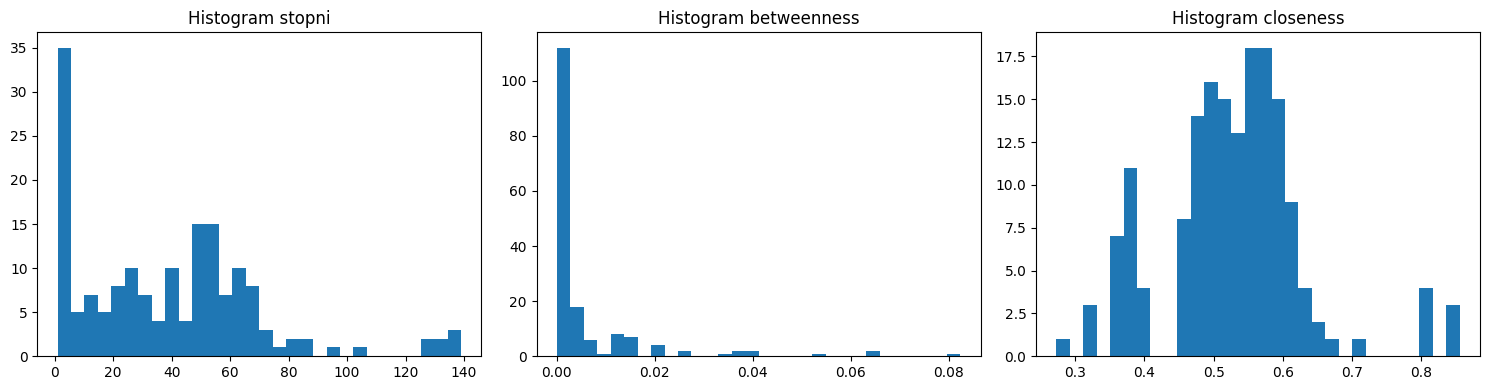

In [106]:
degrees = dict(G_real.degree())
btw = nx.betweenness_centrality(G_real)
cls = nx.closeness_centrality(G_real)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(list(degrees.values()), bins=30)
axes[0].set_title("Histogram stopni")

axes[1].hist(list(btw.values()), bins=30)
axes[1].set_title("Histogram betweenness")

axes[2].hist(list(cls.values()), bins=30)
axes[2].set_title("Histogram closeness")

plt.tight_layout()
plt.show()

In [107]:
nodes = list(G_real.nodes())
tau_db, _ = kendalltau([degrees[n] for n in nodes], [btw[n] for n in nodes])
tau_dc, _ = kendalltau([degrees[n] for n in nodes], [cls[n] for n in nodes])
tau_bc, _ = kendalltau([btw[n] for n in nodes], [cls[n] for n in nodes])

print(f"Kendall degree vs betweenness: {tau_db:.3f}")
print(f"Kendall degree vs closeness:   {tau_dc:.3f}")
print(f"Kendall betweenness vs closeness: {tau_bc:.3f}")

Kendall degree vs betweenness: 0.804
Kendall degree vs closeness:   0.951
Kendall betweenness vs closeness: 0.784


(d) Ile jest komponentów (connected components) znajduje się w grafie? Czy przy takiej reprezentacji danych mogą być wierzchołki bez krawędzi?

In [108]:
print(f"Number of connected components: {nx.number_connected_components(G_real)}")

for i, comp in enumerate(nx.connected_components(G_real)):
    print(f"Component {i}: {len(comp)} nodes")

Number of connected components: 1
Component 0: 167 nodes


(e) Jaka jest średnica grafu i czy jest dużo inna od średniej długościścieżki w grafie?

In [109]:
diameter = nx.diameter(G_real)
avg_path = nx.average_shortest_path_length(G_real)

print(f"Średnica: {diameter}")
print(f"Średnia długość ścieżki: {avg_path:.3f}")

Średnica: 5
Średnia długość ścieżki: 1.967


(f) Stwórz graf na nowo, ale tym razem jako skierowany. Ustaw wagi krawędzi w grafie w taki sposób, aby waga pomiędzy wierzchołkiem v1 a v2 była wyrażona jako liczba wiadomości wysłanych przez v1 do v2 w stosunku do wszystkich wiadomości wysłanych przez węzeł v1.

In [110]:
# Policz ile razy v1 wysłał do v2
edge_counts = df_mail.groupby(["sender", "receiver"]).size().reset_index(name="count")

# Policz wszystkie maile wysłane przez każdego nadawcę
total_sent = df_mail.groupby("sender").size().reset_index(name="total")

# Połącz i oblicz wagę
edge_counts = edge_counts.merge(total_sent, on="sender")
edge_counts["weight"] = edge_counts["count"] / edge_counts["total"]

# Stwórz graf skierowany z wagami
G_directed = nx.from_pandas_edgelist(
    edge_counts,
    source="sender",
    target="receiver",
    edge_attr="weight",
    create_using=nx.DiGraph()
)

print(f"Węzłów: {G_directed.number_of_nodes()}")
print(f"Krawędzi: {G_directed.number_of_edges()}")

Węzłów: 167
Krawędzi: 5784


(g) Sprawdź czy w takim grafie skierowanym można dostać się z każdegowierzchołka do każdego innego

In [111]:
is_strongly = nx.is_strongly_connected(G_directed)
print(f"Silnie spójny: {is_strongly}")

print(f"Silnie spójnych komponentów: {nx.number_strongly_connected_components(G_directed)}")

# Sprawdź też słabą spójność
is_weakly = nx.is_weakly_connected(G_directed)
print(f"Słabo spójny: {is_weakly}")

Silnie spójny: False
Silnie spójnych komponentów: 42
Słabo spójny: True
